# FARK-SIM Agent Initialisation Pipeline using local model

Stratified sampling from Nemotron-Personas-Singapore.

Stratified by: gender × marital_status (rel_status).

Target: **200 agents (104F, 96M)** fitted to M&P 2021 proportions.

Downstream LLM steps add:
- `financial_security_score` (1–5, LLM-inferred)
- `relationship_status` (Single → Single/Dating, LLM-inferred)


Step 1: Load Dataset, inspect

In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import json
import uuid

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ─────────────────────────────────────────────
# 1. LOAD AND INSPECT
# ─────────────────────────────────────────────

ds = load_dataset("nvidia/Nemotron-Personas-Singapore")
df = pd.DataFrame(ds["train"])

print("=== Raw Dataset Columns ===")
print(df.columns.tolist())
print(f"\nTotal records: {len(df)}")
print("\nSample row:")
print(df.iloc[0].to_dict())

c:\Users\chong\OneDrive - Singapore Management University\research\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== Raw Dataset Columns ===
['uuid', 'professional_persona', 'sports_persona', 'arts_persona', 'travel_persona', 'culinary_persona', 'persona', 'cultural_background', 'skills_and_expertise', 'skills_and_expertise_list', 'hobbies_and_interests', 'hobbies_and_interests_list', 'career_goals_and_ambitions', 'sex', 'age', 'marital_status', 'education_level', 'occupation', 'industry', 'planning_area', 'country']

Total records: 148000

Sample row:
{'uuid': 'd792702ec018494e8e49c69120759408', 'professional_persona': 'Yi Peng Yong, known as Danelle, a 20‑year‑old retail operations associate, leverages her methodical planning, bilingual communication, and data‑driven decision‑making to keep inventory flowing smoothly and nurture harmonious vendor relationships while adhering to a strict routine.', 'sports_persona': 'Yi Peng Yong, known as Danelle, enjoys playing golf at Marina Bay Golf Club, follows the Singapore Open and the PGA Tour, and fits short cardio sessions into her weekly routine to c

2. Normalise Fields 

Adjust field names here if Nemotron uses different names

Common Nemotron field names based on HuggingFace docs

In [2]:
FIELD_MAP = {
    "age":            "age",
    "gender":         "sex",                    # or "gender" — check your print above
    "rel_status":     "marital_status",
    "education":      "education_level",
    "occupation":     "occupation",
    "industry":       "industry",
    "planning_area":  "planning_area",
    "persona":        "general_persona",
    "cultural_bg":    "cultural_background",
    "hobbies":        "hobbies_and_interests",
    "career_goals":   "career_goals_and_ambitions",
}

# Rename to internal names for cleanliness
df = df.rename(columns={v: k for k, v in FIELD_MAP.items()})

cols = [
    "age",
    "gender",
    "rel_status",
    "education",
    "occupation",
    "industry",
    "planning_area",
    "persona",
    "cultural_bg",
    "hobbies",
    "career_goals"
]

df = df[cols].copy()

# Filter age 21–45
df = df[(df["age"] >= 21) & (df["age"] <= 45)].copy()

# Normalise gender
df["gender"] = df["gender"].str.lower().str.strip()
df = df[df["gender"].isin(["male", "female"])].copy()

# Normalise relationship status (dataset has single/married/divorced)
df["rel_status"] = df["rel_status"].str.lower().str.strip()
df = df[df["rel_status"].isin(["single", "married"])].copy()

print(f"\nAfter filtering (age 21-45, valid gender/rel): {len(df)} records")



After filtering (age 21-45, valid gender/rel): 62669 records


In [3]:
TARGETS = {
    ("male",   "single"):  50,
    ("female", "single"):  47,
    ("male",   "married"): 46,
    ("female", "married"): 57,
}
 
assert sum(TARGETS.values()) == 200, "Total must be 200"
assert sum(v for (g,_),v in TARGETS.items() if g == "male")   == 96,  "Male must be 96"
assert sum(v for (g,_),v in TARGETS.items() if g == "female") == 104, "Female must be 104"
 

4. STRATIFIED SAMPLING (age/education preserved as-is from Nemotron)

In [4]:
sampled_frames = []
sampling_log = {}
 
for (gender, rel), n in TARGETS.items():
    cell = df[(df["gender"] == gender) & (df["rel_status"] == rel)]
    available = len(cell)
 
    if available >= n:
        sample = cell.sample(n, random_state=RANDOM_SEED)
        method = "without_replacement"
    else:
        sample = cell.sample(n, replace=True, random_state=RANDOM_SEED)
        method = f"with_replacement (only {available} available)"
        print(f"WARN ({gender}, {rel}): needed {n}, had {available} -- sampled with replacement")
 
    sampling_log[(gender, rel)] = {"needed": n, "available": available, "method": method}
    sampled_frames.append(sample)
 
agents_df = pd.concat(sampled_frames).reset_index(drop=True)

5. ASSIGN IDs + NEUTRAL TPB BASELINE (Step 0)

In [5]:
 
agents_df["agent_id"] = [f"agent_{i:03d}" for i in range(1, len(agents_df) + 1)]

6. POST-HOC PLAUSIBILITY CHECK vs M&P 2021 Annex A

We did NOT fit age or education -- these are whatever Nemotron gave us. This block just reports them so you can note alignment/divergence.

In [6]:
print("\n=== Post-Hoc Check vs M&P 2021 Annex A ===")
print(f"\nTotal agents: {len(agents_df)}  (expect 200)")
 
print("\nGender x Marital (stratified -- should match targets exactly):")
print(pd.crosstab(agents_df["gender"], agents_df["rel_status"]).to_string())
 
print("\nRelationship status (after dating subdivision):")
print(agents_df["rel_status"].value_counts().to_string())
 
# Age -- M&P targets shown for reference (NOT fitted)
print("\nAge band -- SINGLE  [M&P ref: 21-25=30%, 26-30=34%, 31-35=18%, 36-40=10%, 41-45=9%]")
single = agents_df[agents_df["rel_status"] == "single"]
print((pd.cut(single["age"], [20,25,30,35,40,45],
              labels=["21-25","26-30","31-35","36-40","41-45"])
       .value_counts(normalize=True).sort_index()*100).round(1).to_string())
 
print("\nAge band -- MARRIED [M&P ref: 21-25=1%, 26-30=9%, 31-35=24%, 36-40=30%, 41-45=37%]")
married = agents_df[agents_df["rel_status"] == "married"]
print((pd.cut(married["age"], [20,25,30,35,40,45],
              labels=["21-25","26-30","31-35","36-40","41-45"])
       .value_counts(normalize=True).sort_index()*100).round(1).to_string())
 
# Education -- M&P targets shown for reference (NOT fitted)
print("\nEducation -- SINGLE  [M&P ref: Secondary<=12%, Diploma/A=34%, Degree+=55%]")
print(single["education"].value_counts(normalize=True).mul(100).round(1).to_string())
 
print("\nEducation -- MARRIED [M&P ref: Secondary<=16%, Diploma/A=28%, Degree+=56%]")
print(married["education"].value_counts(normalize=True).mul(100).round(1).to_string())


=== Post-Hoc Check vs M&P 2021 Annex A ===

Total agents: 200  (expect 200)

Gender x Marital (stratified -- should match targets exactly):
rel_status  married  single
gender                     
female           57      47
male             46      50

Relationship status (after dating subdivision):
rel_status
married    103
single      97

Age band -- SINGLE  [M&P ref: 21-25=30%, 26-30=34%, 31-35=18%, 36-40=10%, 41-45=9%]
age
21-25    35.1
26-30    33.0
31-35    20.6
36-40     7.2
41-45     4.1

Age band -- MARRIED [M&P ref: 21-25=1%, 26-30=9%, 31-35=24%, 36-40=30%, 41-45=37%]
age
21-25     2.9
26-30     9.7
31-35    21.4
36-40    30.1
41-45    35.9

Education -- SINGLE  [M&P ref: Secondary<=12%, Diploma/A=34%, Degree+=55%]
education
University                       52.6
Post Secondary (Non-Tertiary)    14.4
Polytechnic                      11.3
Other Diploma                    11.3
Secondary                         7.2
Lower Secondary                   2.1
Primary                   

## 7. LLM-Inferred Attributes (OpenRouter, free models)

Generate two LLM-inferred fields per agent:

- `financial_security_score` (1–5) — inferred from education, occupation, industry, age, planning area
- `relationship_status` (Single / Dating) — for single agents only, inferred from persona, age, education, hobbies, cultural background, career goals

Reasoning is preserved alongside each score / label for traceability.


In [12]:
import os
import json
import time
import openai
from dotenv import load_dotenv

load_dotenv()

# We only need the Local URL now. Make sure your .env has: 
# LOCAL_LLM_URL="http://localhost:8000/v1"
LOCAL_LLM_URL = os.getenv("LOCAL_LLM_URL")

if not LOCAL_LLM_URL:
    raise RuntimeError("Set LOCAL_LLM_URL in .env before running this cell")

# Connect client directly to the SSH tunnel local port
local_client = openai.OpenAI(
    base_url=LOCAL_LLM_URL,
    api_key="vllm-placeholder"
)

# Limit how many agents the loop below will process.
# Set TEST_N = 5  -> dry-run on first 5 agents
# Set TEST_N = None -> run full dataset (no OpenRouter caps to worry about!)
TEST_N = None

def call_local_llm(system_prompt: str, user_prompt: str, max_retries: int = 3) -> dict:
    """
    Queries your school's local L40S GPU vLLM server via the SSH tunnel.
    Uses native json_schema constraints to guarantee correct output structure.
    """
    for attempt in range(max_retries):
        try:
            response = local_client.chat.completions.create(
                model="meta-llama/Meta-Llama-3.1-8B-Instruct",
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt},
                ],
                # Tell vLLM to output JSON generally
                response_format={"type": "json_object"},
                # Inject the specific schema constraint into the extra_body parameter
                extra_body={
                    "guided_json": {
                        "type": "object",
                        "properties": {
                            "score": {"type": "integer"},
                            "status": {"type": "string"},
                            "reasoning": {"type": "string"}
                        },
                        "required": ["score", "status", "reasoning"]
                    }
                },
                temperature=0.2
            )
            
            content = response.choices[0].message.content
            return json.loads(content)
            
        except Exception as e:
            wait = 2 ** attempt
            print(f"    Attempt {attempt+1} failed locally: {e}. Retrying in {wait}s")
            time.sleep(wait)
            
    raise RuntimeError("Local LLM exhausted retries.")

# Local Server Sanity check 
print("Testing connection to school server via SSH tunnel...")
try:
    _test = call_local_llm(
        "You respond only with valid JSON.",
        'Return a json object with a score of 100, status "ok", and reasoning "tunnel is working".'
    )
    print("Sanity check PASSED:", _test)
    print(f"Ready to process. TEST_N = {TEST_N}")
except Exception as e:
    print("Sanity check FAILED. Check your SSH terminal window. Error:", e)

Testing connection to school server via SSH tunnel...
Sanity check PASSED: {'score': 100, 'status': 'ok', 'reasoning': 'tunnel is working'}
Ready to process. TEST_N = None


### 7a. Financial Security Score (1–5)

LLM infers SES band from education, occupation, industry, age, and planning area. Reasoning is preserved for traceability.

In [13]:
FIN_SYSTEM_PROMPT = """You are a Singapore socio-economic analyst. Given an adult's demographic profile, estimate their financial security on a 1-5 scale where:
1 = Low (financially struggling, minimal savings/assets)
2 = Lower-middle
3 = Middle (stable, modest savings)
4 = Upper-middle
5 = Upper (high income, substantial assets)

Use cues: occupation seniority, industry pay norms in Singapore, education level, Singapore planning area (HDB heartland vs private estate / mature vs non-mature), and age (career stage). Be calibrated — most working adults are 2-4, not 5.

Respond ONLY with valid JSON: {"score": <int 1-5>, "reasoning": "<one or two sentences>"}"""

def build_fin_prompt(row) -> str:
    return (
        f"Age: {row['age']}\n"
        f"Gender: {row['gender']}\n"
        f"Education level: {row['education']}\n"
        f"Occupation: {row['occupation']}\n"
        f"Industry: {row.get('industry') or 'Not specified'}\n"
        f"Singapore planning area: {row['planning_area']}"
    )

# Initialise output cols (so partial test runs leave None for skipped agents)
agents_df["financial_security_score"]     = None
agents_df["financial_security_reasoning"] = None

target_df = agents_df.head(TEST_N) if TEST_N else agents_df
print(f"Running financial_security_score for {len(target_df)} agent(s)...\n")

for i, row in target_df.iterrows():
    print(f"[{i+1:3d}/{len(agents_df)}] {row['agent_id']}", end=" ")
    try:
        result = call_local_llm(FIN_SYSTEM_PROMPT, build_fin_prompt(row))
        score = int(result["score"])
        reasoning = str(result["reasoning"])
        if not 1 <= score <= 5:
            raise ValueError(f"score out of range: {score}")
    except Exception as e:
        print(f"FAILED -> {e}")
        score, reasoning = None, f"ERROR: {e}"
    else:
        print(f"-> {score}")
    agents_df.at[i, "financial_security_score"]     = score
    agents_df.at[i, "financial_security_reasoning"] = reasoning

print("\n=== Distribution of financial_security_score ===")
print(agents_df["financial_security_score"].value_counts(dropna=False))

Running financial_security_score for 200 agent(s)...

[  1/200] agent_001 -> 3
[  2/200] agent_002 -> 1
[  3/200] agent_003 -> 3
[  4/200] agent_004 -> 3
[  5/200] agent_005 -> 3
[  6/200] agent_006 -> 2
[  7/200] agent_007 -> 3
[  8/200] agent_008 -> 2
[  9/200] agent_009 -> 1
[ 10/200] agent_010 -> 1
[ 11/200] agent_011 -> 1
[ 12/200] agent_012 -> 1
[ 13/200] agent_013 -> 3
[ 14/200] agent_014 -> 4
[ 15/200] agent_015 -> 3
[ 16/200] agent_016 -> 3
[ 17/200] agent_017 -> 3
[ 18/200] agent_018 -> 2
[ 19/200] agent_019 -> 4
[ 20/200] agent_020 -> 3
[ 21/200] agent_021 -> 2
[ 22/200] agent_022 -> 1
[ 23/200] agent_023 -> 2
[ 24/200] agent_024 -> 4
[ 25/200] agent_025 -> 3
[ 26/200] agent_026 -> 1
[ 27/200] agent_027 -> 2
[ 28/200] agent_028 -> 2
[ 29/200] agent_029 -> 3
[ 30/200] agent_030 -> 1
[ 31/200] agent_031 -> 3
[ 32/200] agent_032 -> 3
[ 33/200] agent_033 -> 3
[ 34/200] agent_034 -> 4
[ 35/200] agent_035 -> 3
[ 36/200] agent_036 -> 3
[ 37/200] agent_037 -> 3
[ 38/200] agent_038 -

### 7b. Relationship Status (Single → Single / Dating)

Single agents are LLM-judged into `Single` or `Dating` from persona, age, education, career goals, hobbies, and cultural background. Married agents pass through unchanged with source `raw_marital_status`.

In [14]:
REL_SYSTEM_PROMPT = """You are a behavioural researcher reading an adult's profile to judge whether they are most plausibly:
- "Single": not in any romantic relationship right now
- "Dating": in a non-marital romantic relationship (boyfriend/girlfriend, partner, courtship)

Weigh cues such as: career intensity, lifestyle and hobbies, age, persona narrative (any mention of partners, dating, social life, family orientation), cultural and educational background. Do not default to one label; reason from the specific profile.

Respond ONLY with valid JSON: {"status": "Single" | "Dating", "reasoning": "<one or two sentences>"}"""

def build_rel_prompt(row) -> str:
    return (
        f"Age: {row['age']}\n"
        f"Gender: {row['gender']}\n"
        f"Education level: {row['education']}\n"
        f"Occupation: {row['occupation']}\n"
        f"Persona: {row['persona']}\n"
        f"Cultural background: {row['cultural_bg']}\n"
        f"Hobbies and interests: {row['hobbies']}\n"
        f"Career goals: {row['career_goals']}"
    )

# Initialise output cols (so partial test runs leave None for skipped agents)
agents_df["relationship_status"]           = None
agents_df["relationship_status_source"]    = None
agents_df["relationship_status_reasoning"] = None

target_df = agents_df.head(TEST_N) if TEST_N else agents_df
print(f"Running relationship_status for {len(target_df)} agent(s) "
      f"(LLM only called for Single agents)...\n")

for i, row in target_df.iterrows():
    if row["rel_status"] != "single":
        agents_df.at[i, "relationship_status"]        = "Married"
        agents_df.at[i, "relationship_status_source"] = "raw_marital_status"
        agents_df.at[i, "relationship_status_reasoning"] = None
        continue

    print(f"[{i+1:3d}/{len(agents_df)}] {row['agent_id']}", end=" ")
    try:
        result = call_local_llm(REL_SYSTEM_PROMPT, build_rel_prompt(row))
        status = str(result["status"]).strip().title()
        if status not in {"Single", "Dating"}:
            raise ValueError(f"unexpected status: {status}")
        reasoning = str(result["reasoning"])
    except Exception as e:
        print(f"FAILED -> {e}")
        status, reasoning = "Single", f"ERROR: {e}"  # safe fallback
    else:
        print(f"-> {status}")

    agents_df.at[i, "relationship_status"]           = status
    agents_df.at[i, "relationship_status_source"]    = "llm_imputed"
    agents_df.at[i, "relationship_status_reasoning"] = reasoning

print("\n=== Distribution of relationship_status ===")
print(agents_df["relationship_status"].value_counts(dropna=False))

Running relationship_status for 200 agent(s) (LLM only called for Single agents)...

[  1/200] agent_001 -> Single
[  2/200] agent_002 -> Single
[  3/200] agent_003 -> Single
[  4/200] agent_004 -> Dating
[  5/200] agent_005 -> Single
[  6/200] agent_006 -> Single
[  7/200] agent_007 -> Single
[  8/200] agent_008 -> Single
[  9/200] agent_009 -> Single
[ 10/200] agent_010 -> Single
[ 11/200] agent_011 -> Single
[ 12/200] agent_012 -> Single
[ 13/200] agent_013 -> Dating
[ 14/200] agent_014 -> Single
[ 15/200] agent_015 -> Single
[ 16/200] agent_016 -> Single
[ 17/200] agent_017 -> Single
[ 18/200] agent_018 -> Single
[ 19/200] agent_019 -> Single
[ 20/200] agent_020 -> Single
[ 21/200] agent_021 -> Single
[ 22/200] agent_022 -> Single
[ 23/200] agent_023 -> Single
[ 24/200] agent_024 -> Dating
[ 25/200] agent_025 -> Single
[ 26/200] agent_026 -> Single
[ 27/200] agent_027 -> Single
[ 28/200] agent_028 -> Single
[ 29/200] agent_029 -> Single
[ 30/200] agent_030 -> Single
[ 31/200] agent

In [15]:
# print agents_df score and reasoning for llm derived fields
print("\n=== Sample of LLM-derived relationship_status with reasoning ===")
print(agents_df[["agent_id", "relationship_status", "relationship_status_reasoning"]]
      .head(TEST_N).to_string(index=False)) 

# print agents_df score and reasoning for financial_security_score
print("\n=== Sample of LLM-derived financial_security_score with reasoning ===")
print(agents_df[["agent_id", "financial_security_score", "financial_security_reasoning"]]
      .head(TEST_N).to_string(index=False))


=== Sample of LLM-derived relationship_status with reasoning ===
 agent_id relationship_status                                                                                                                                                                                                                                                                                                                                                               relationship_status_reasoning
agent_001              Single                                                                                                              Boon Juay's persona narrative focuses on his career goals, hobbies, and personal development, with no mention of a romantic partner or social life that suggests a relationship, and his disciplined lifestyle and career ambitions suggest a strong focus on personal growth.
agent_002              Single                                               Mohamed Jaafar's persona narrative foc

## 8. Export to `agents_initialised.json`

In [16]:
import json

def row_to_agent(row):
    fin_score = row.get("financial_security_score")
    return {
        "agent_id":               row["agent_id"],
        "age":                    int(row["age"]),
        "gender":                 str(row["gender"]).title(),

        # Raw marital_status from Nemotron (Single / Married)
        "marital_status":         str(row["rel_status"]).title(),

        # LLM-derived relationship status (Single / Dating / Married)
        "relationship_status":            row.get("relationship_status"),
        "relationship_status_source":     row.get("relationship_status_source"),
        "relationship_status_reasoning":  row.get("relationship_status_reasoning"),

        "education":              row.get("education"),
        "occupation":              row.get("occupation"),
        "industry":                row.get("industry"),
        "planning_area":           row.get("planning_area"),

        # LLM-inferred SES band (1-5) with reasoning
        "financial_security_score":     (int(fin_score) if pd.notna(fin_score) else None),
        "financial_security_reasoning": row.get("financial_security_reasoning"),

        "general_persona":         row.get("persona"),
        "cultural_background":     row.get("cultural_bg"),
        "hobbies_and_interests":   row.get("hobbies"),
        "career_goals":            row.get("career_goals"),

        # TPB belief state -- neutral baseline (updated after seed memories)
        "belief_state": {
            "attitude_score":           3,
            "subjective_norm_score":    3,
            "pbc_score":                3,
            "fertility_intention_dist": None,
        },

        # Memory stream -- populated in next pipeline step
        "memory_stream": [],
    }

agents = [row_to_agent(row) for _, row in agents_df.iterrows()]

with open("agents_llama_initialised.json", "w", encoding="utf-8") as f:
    json.dump(agents, f, indent=2, ensure_ascii=False)

print(f"\nSaved {len(agents)} agents to agents_llama_initialised.json")
print("Next step: generate seed memories per agent")


Saved 200 agents to agents_llama_initialised.json
Next step: generate seed memories per agent


## 9. Comparison vs Nemotron initialisation

`agents_initialised.json` (OpenRouter, `nvidia/nemotron-3-super-120b-a12b:free`) and `agents_llama_initialised.json` (local `meta-llama/Meta-Llama-3.1-8B-Instruct`) share the same pipeline and schema — only the two LLM-inferred fields can differ:

- `financial_security_score` (1–5)
- `relationship_status` (Single → Single/Dating, for the 97 LLM-imputed agents)

`src/compare_initialisations.py` prints the full agreement report and exports a per-agent diff to `outputs/initialisation_comparison.csv`, which the cells below visualise.

In [20]:
# Run the comparison (prints agreement report, refreshes the CSV)
%run src/compare_initialisations.py

import pandas as pd
cmp_df = pd.read_csv("outputs/initialisation_comparison.csv")
print(f"\nLoaded {len(cmp_df)} agents for plotting")

FIELD-LEVEL DIFFERENCES (count of agents where field differs)
                        field  agents_differing
                          age                 0
                     agent_id                 0
                 belief_state                 0
                 career_goals                 0
          cultural_background                 0
                    education                 0
 financial_security_reasoning               200
     financial_security_score                72
                       gender                 0
              general_persona                 0
        hobbies_and_interests                 0
                     industry                 0
               marital_status                 0
                memory_stream                 0
                   occupation                 0
                planning_area                 0
          relationship_status                 3
relationship_status_reasoning                97
   relationship_status_sou

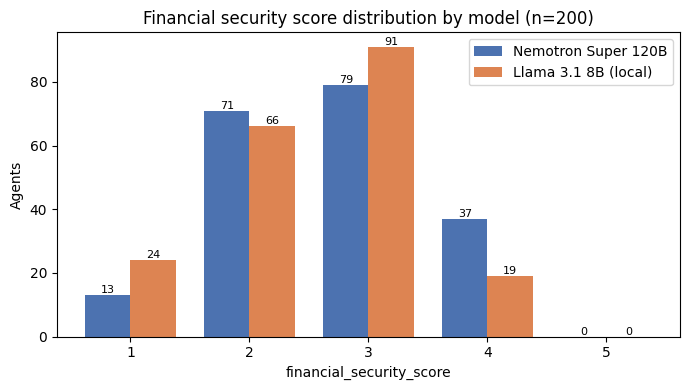

In [22]:
# Financial security score distributions, side by side
import matplotlib.pyplot as plt
import numpy as np

scores = [1, 2, 3, 4, 5]
nem_counts = cmp_df["fin_score_nemotron"].value_counts().reindex(scores, fill_value=0)
lla_counts = cmp_df["fin_score_llama"].value_counts().reindex(scores, fill_value=0)

x = np.arange(len(scores))
w = 0.38
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w/2, nem_counts, w, label="Nemotron Super 120B", color="#4c72b0")
ax.bar(x + w/2, lla_counts, w, label="Llama 3.1 8B (local)", color="#dd8452")
ax.set_xticks(x, scores)
ax.set_xlabel("financial_security_score")
ax.set_ylabel("Agents")
ax.set_title("Financial security score distribution by model (n=200)")
ax.legend()
for bars in ax.containers:
    ax.bar_label(bars, fontsize=8)
plt.tight_layout()
plt.show()

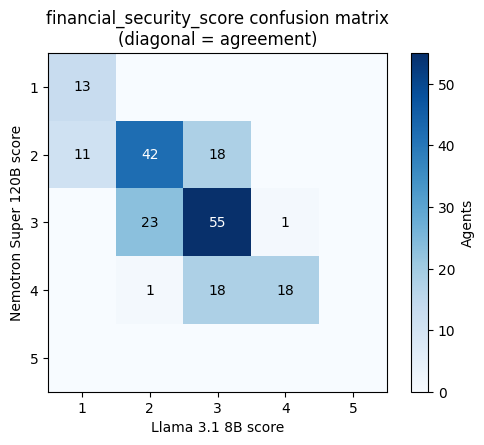

In [23]:
# Confusion matrix heatmap: where the two models agree / disagree
conf = pd.crosstab(cmp_df["fin_score_nemotron"], cmp_df["fin_score_llama"]) \
         .reindex(index=scores, columns=scores, fill_value=0)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(conf, cmap="Blues")
ax.set_xticks(range(5), scores)
ax.set_yticks(range(5), scores)
ax.set_xlabel("Llama 3.1 8B score")
ax.set_ylabel("Nemotron Super 120B score")
ax.set_title("financial_security_score confusion matrix\n(diagonal = agreement)")
for r in range(5):
    for c in range(5):
        v = conf.iat[r, c]
        if v:
            ax.text(c, r, v, ha="center", va="center",
                    color="white" if v > conf.values.max() / 2 else "black")
fig.colorbar(im, ax=ax, label="Agents")
plt.tight_layout()
plt.show()

In [25]:
# Financial security score disagreements, with both models' reasoning
fin_flips = cmp_df.loc[
    cmp_df["fin_delta"] != 0,
    ["agent_id", "fin_score_nemotron", "fin_score_llama", "fin_delta",
     "fin_reasoning_nemotron", "fin_reasoning_llama"],
].sort_values("fin_delta", key=abs, ascending=False)

print(f"{len(fin_flips)} disagreement(s) out of {len(cmp_df)} agents, largest deltas first")

with pd.option_context("display.max_colwidth", None, "display.max_rows", None):
    display(fin_flips)

72 disagreement(s) out of 200 agents, largest deltas first


,agent_id,fin_score_nemotron,fin_score_llama,fin_delta,fin_reasoning_nemotron,fin_reasoning_llama
91,agent_092,4,2,-2,"At 28 with a diploma in an associate professional role in professional services, likely earning a moderate-to-good salary; residing in Bukit Timah, a private/mature estate, indicates above-average financial capacity, placing her in the upper-middle bracket.","The associate professional or technician role typically has a lower to middle salary range in Singapore, and the education level of an other diploma may limit career advancement and earning potential."
1,agent_002,2,1,-1,"With only lower secondary education and a plant/machine operator role in manufacturing, the individual likely earns a modest wage typical for entry‑level blue‑collar work in Singapore. Living in Punggol (an HDB heartland) at age 29 suggests limited asset accumulation, placing financial security in the lower‑middle range.","Given the individual's lower secondary education and occupation in manufacturing, which typically has lower pay scales, their financial security is likely to be low. Additionally, Punggol being a mature estate with relatively higher housing costs may further strain their finances."
7,agent_008,3,2,-1,"At 33, an associate professional/technician in manufacturing in Hougang likely earns a moderate monthly wage (around SGD 3k‑4k) with some savings from an HDB flat, placing him in the middle of the financial security spectrum.","This individual is in a stable career stage, but may face limited career growth and income potential due to his occupation and education level, typical of the lower-middle class in Singapore."
5,agent_006,3,2,-1,"A 26‑year‑old university graduate working as an associate professional in public administration likely earns a moderate salary (~SGD 3‑4k) with stable government employment, allowing modest savings but limited wealth accumulation at this early career stage.","The occupation and industry are relatively stable, but the associate professional or technician role typically has a lower salary range compared to other professions, and Bukit Panjang is considered a heartland area with relatively affordable housing."
9,agent_010,2,1,-1,"At 29 with only secondary education and working as a plant/machine operator in manufacturing, earnings are likely modest, placing the individual in the lower-middle bracket, especially residing in a mature HDB heartland like Geylang.","Given the individual's secondary education and occupation as a plant or machine operator, their earning potential is likely to be lower, and their financial security may be compromised by the high cost of living in Singapore, particularly in mature estates like Geylang."
21,agent_022,2,1,-1,"At 21 with only secondary education and an entry‑level service/sales job in wholesale & retail, income is likely modest and savings limited; living in the HDB heartland of Bukit Panjang further points to a lower‑middle financial position.","At 21, he is likely in the early stages of his career with limited work experience and earning potential, making it challenging to achieve financial stability."
24,agent_025,4,3,-1,"At 29, a university‑educated senior manager in ICT likely commands a solid salary above the national median, providing stable savings and asset accumulation despite residing in an HDB heartland.","Jurong West is a mature HDB heartland area, which may have a lower cost of living compared to private estates, contributing to a higher score."
8,agent_009,2,1,-1,"At 26 with only lower secondary education and a production craftsman role in construction, earnings are likely modest, and living in a Tampines HDB heartland suggests limited asset accumulation, placing financial security in the lower‑middle range.","At 26, with a lower secondary education and a production craftsman role in the construction industry, which is generally lower-paying, he is likely to be in an entry-level position with limited career progression and modest income."


In [24]:
# Relationship status disagreements (only possible among the 97 llm_imputed agents)
flips = cmp_df.loc[
    ~cmp_df["rel_status_match"],
    ["agent_id", "rel_status_nemotron", "rel_status_llama",
     "rel_reasoning_nemotron", "rel_reasoning_llama"],
]
print(f"{len(flips)} disagreement(s) out of "
      f"{(cmp_df['rel_status_source'] == 'llm_imputed').sum()} LLM-imputed agents")

with pd.option_context("display.max_colwidth", None):
    display(flips)

3 disagreement(s) out of 97 LLM-imputed agents


,agent_id,rel_status_nemotron,rel_status_llama,rel_reasoning_nemotron,rel_reasoning_llama
3,agent_004,Single,Dating,"The profile emphasizes Zi Lim's sociable hobbies, career ambitions, and family-oriented upbringing but contains no reference to a romantic partner, dating, or relationship status.","Zi's sociable nature, emphasis on social activities, and documented hobbies suggest a person who values relationships and community, which is consistent with someone in a romantic relationship. His overall persona narrative does not explicitly rule out a romantic partner, and his focus on personal development and career goals is typical of someone who has a supportive partner."
12,agent_013,Single,Dating,"The profile emphasizes career drive, socializing with friends, and personal hobbies, with no mention of a romantic partner or relationship status.","Kah Kiat Lim's outgoing personality, love for socializing, and active lifestyle suggest that he is likely in a romantic relationship, and his career goals and ambitions do not indicate a lack of focus on personal life."
23,agent_024,Single,Dating,"The profile highlights Kelvin’s career intensity, schedule‑driven habits, and extensive solo or group‑friend activities, with no mention of a romantic partner, spouse, or dating life. While he emphasizes family traditions and filial piety, there are no cues indicating an ongoing non‑marital romantic relationship.","Kelvin's sociable energy, group activities, and volunteering suggest a well-rounded personality with a strong social network, which is more consistent with someone in a romantic relationship."
